In [ ]:
library(ggplot2)
library(dplyr)
library(forcats)
library(scales)

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




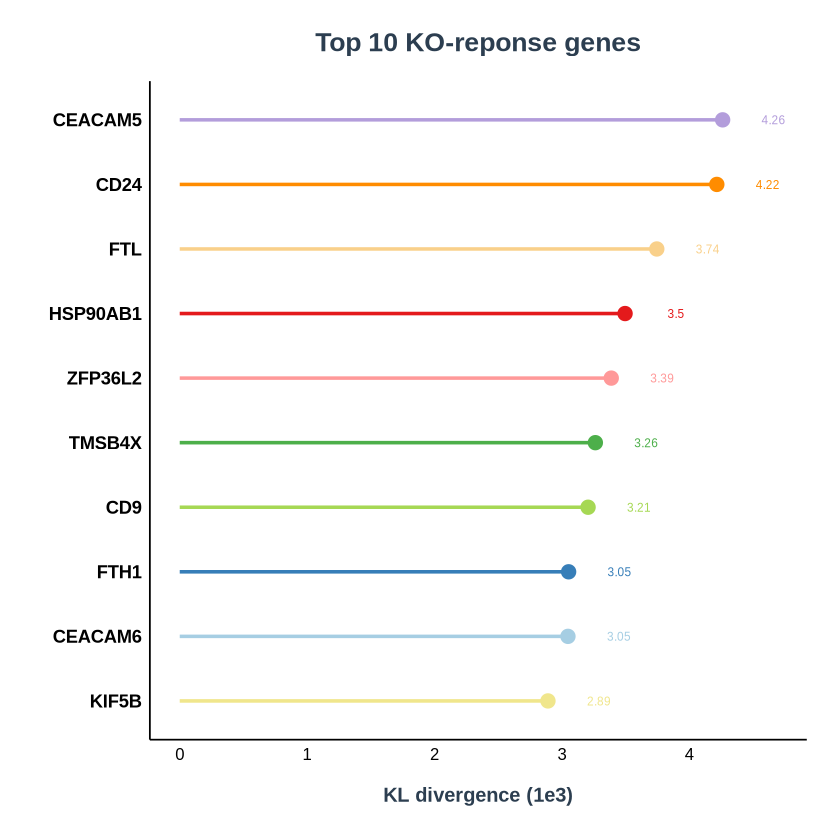

In [1]:
# Fig 6B
cd44_rank <- read.csv("../Data/CRC_all_CD44_ranked.csv",row.names=1)
cd44_rank <- cd44_rank[-1,]


df_data <- data.frame(
  gene = rownames(cd44_rank[1:10,]),
  KL = cd44_rank[1:10,1]/1000
)

desired_order <- rownames(cd44_rank[1:10,])
df_data$gene <- factor(df_data$gene, levels = rev(desired_order))


cell_colors <- c(
"#B39DDB", 
"#FF8C00", 
"#F9D08A", 
"#E41A1C", 
"#FF9999", 
"#4DAF4A", 
"#A6D854", 
"#377EB8", 
"#A6CEE3",  
'#F0E68C'
)
names(cell_colors) <- desired_order
max_kl_value <- max(df_data$KL)

ggplot(df_data, aes(x = KL, y = gene)) +
  
  
  geom_segment(aes(x = 0, xend = KL, y = gene, yend = gene, color = gene), 
               linewidth = 1) + 
  
  
  geom_point(aes(fill = gene, color = gene), 
             shape = 21, 
             size = 3,    
             stroke = 1) + 
  
  
  geom_text(aes(label = round(KL,2),color = gene), 
            nudge_x = 0.4,
            size = 2.5) +    
  
  
  scale_color_manual(values = cell_colors) +
  scale_fill_manual(values = cell_colors) + 
  
  
  expand_limits(x = 0) + 
  coord_cartesian(xlim = c(0, max(df_data$KL) * 1.1)) + 
  
  
  labs(
    title = "Top 10 KO-reponse genes",
    x = "KL divergence (1e3)",
    y = NULL 
  ) +
  
  
  theme_minimal() + 
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5, color = "#2C3E50", margin = margin(b = 15)),
    axis.title.x = element_text(face = "bold", size = 12, color = "#2C3E50", margin = margin(t = 15)),
    axis.title.y = element_blank(), 
    axis.text.y = element_text(size = 11, face = "bold", color = "black"), 
    axis.text.x = element_text(size = 10, color = "black"),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(), 
    panel.border = element_blank(),     
    axis.line.x = element_line(color = "black", linewidth = 0.5), 
    
    axis.line.y = element_line(color = "black", linewidth = 0.5),
    legend.position = "none", 
    plot.margin = margin(20, 20, 20, 20) 
  )

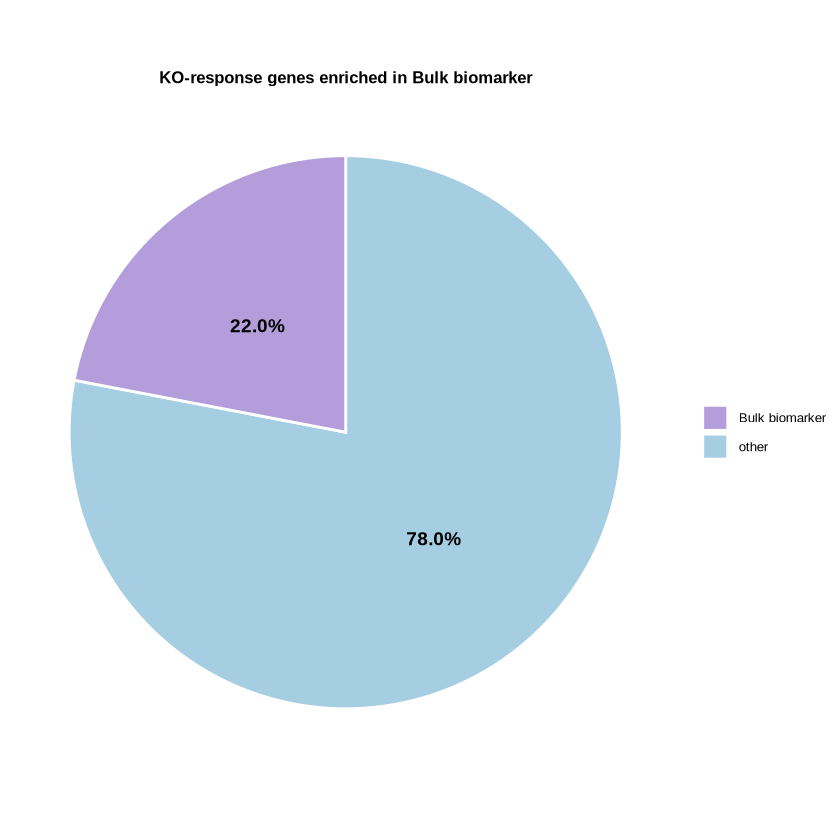

In [2]:
# Fig 6E
data <- data.frame(
  category = c("Bulk biomarker", "other"),
  value = c(31/141, 1-(31/141)) 
)


data_for_plot <- data %>%
  arrange(desc(category)) %>% 
  mutate(
    percentage = value / sum(value),
    label_text = scales::percent(percentage, accuracy = 0.1), 
    y_position = cumsum(percentage) - 0.5 * percentage 
  )


pie_chart <- ggplot(data_for_plot, aes(x = "", y = percentage, fill = category)) +
  geom_bar(stat = "identity", width = 1, color = "white", linewidth = 0.8) +
  coord_polar(theta = "y") +
  geom_text(aes(y = y_position, label = label_text),
            color = "black", size = 4, fontface = "bold") +
  labs(
    title = "KO-response genes enriched in Bulk biomarker",
    fill = NULL,
    x = NULL, y = NULL
  ) +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 10, face = "bold"),
    legend.position = "right",
    #legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 8),
    panel.background = element_rect(fill = "white", colour = NA),
    plot.background = element_rect(fill = "white", colour = NA)
  ) +
  scale_fill_manual(values = c("#B39DDB","#A6CEE3"))


print(pie_chart)


In [3]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS:   /home/amax/anaconda3/envs/zxc/lib/libblas.so.3.9.0 
LAPACK: /home/amax/anaconda3/envs/zxc/lib/liblapack.so.3.9.0  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] scales_1.4.0  forcats_1.0.1 dplyr_1.2.1   ggplot2_4.0.3

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.7.3        cli_3.6.6          rlang_1.2.0       
 [5] g

In [ ]:
# python

In [ ]:
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
# Fig 6C
ranked = pd.read_csv('../Data/CRC_all_CD44_ranked.csv',index_col=0)

my_genes = list(ranked.index)
my_genes = [gene for gene in my_genes if gene != 'CD44']


gene_sets = ['GO_Biological_Process_2025']
enr = gp.enrichr(gene_list=my_genes,
                 gene_sets=gene_sets,
                 organism='human', 
                 outdir=None,      
                 cutoff=0.05       
                 )

results_df = enr.results
significant_results = results_df[results_df['Adjusted P-value'] < 0.05]
print(significant_results[['Term', 'Overlap', 'Adjusted P-value']].head())


significant_results.Term = significant_results.Term.str.split('(',expand=True)[0].str.strip()
gp.dotplot(significant_results, 
                 column="Adjusted P-value", 
                 title="GO Enrichment Dotplot",
                 #top_term=10, 
                 figsize=(6, 6),
                 cmap='Purples') 
plt.show()

In [ ]:
# Fig 6D
gene_sets = ['KEGG_2021_Human']
enr = gp.enrichr(gene_list=my_genes,
                 gene_sets=gene_sets,
                 organism='human', 
                 outdir=None,      
                 cutoff=0.05       
                 )

results_df = enr.results
significant_results = results_df[results_df['Adjusted P-value'] < 0.05]
print(significant_results[['Term', 'Overlap', 'Adjusted P-value']].head())

ax1 = gp.barplot(enr.results, 
                 column="Adjusted P-value", 
                 title="KEGG",
                 top_term=10, 
                 figsize=(5, 4), 
                 color='#F0E68C')
plt.show()